# Оценка количества целевых эпох в самой маленькой валидационной подвыборке для каждого испытуемого в Train и Benchmark выборках

**Зачем?** Чтобы убедиться, что для каждого субъекта достаточно записей, для оценки модели на разном проценте калибровочных данных.

**Кого будем отсекать?** Испытуемых, для которых при разбиении калибровочной подвыборки (р=10%) на train/val (80%/20%) в val-подвыборке остаётся меньше 2 целевых эпох.


Для каждого субъекта (отдельно для train и benchmark):

1. Загружает y из .npz

2. Загружает calib_idx[10] из .json

3. Делает тот же split, что будет в обучении:

- train/val = 80/20

- stratify

- seed = 2026

4. Считает:

- n_pos_val

- n_pos_train

5. Собирает таблицу

6. Показывает:

- сколько субъектов имеют 0 target в val

- распределение

In [9]:
# Импорты и конфиг
from pathlib import Path
import json
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ===== CONFIG =====
BASE_DIR = Path(r"C:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\Выборки\BigP300BCI") 

DATA_DIR = BASE_DIR / "downstream"
SPLITS_DIR = DATA_DIR / "splits"

VAL_FRAC = 0.2
SEED = 2026
P = 10

In [10]:
# Функции загрузки
def load_npz_y(path: Path):
    data = np.load(path, allow_pickle=True)
    return data["y"].astype(int)


def load_split(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def get_calib_idx(split, p=10):
    # под твою структуру
    if "calib_idx" in split:
        return np.array(split["calib_idx"][str(p)], dtype=int)
    
    # fallback
    return np.array(split[f"calib_{p}"], dtype=int)

In [11]:
# Обработка одного субъекта 
def process_subject(subject_id, npz_path, split_path):
    y = load_npz_y(npz_path)
    split = load_split(split_path)

    calib_idx = get_calib_idx(split, p=P)
    y_calib = y[calib_idx]

    # если вдруг вообще нет target — сразу фиксируем
    if (y_calib == 1).sum() == 0:
        return {
            "subject_id": subject_id,
            "n_calib": len(calib_idx),
            "n_pos_calib": 0,
            "n_pos_train": 0,
            "n_pos_val": 0,
            "error": "no_target_in_calib"
        }

    # stratified split
    try:
        idx_train, idx_val = train_test_split(
            calib_idx,
            test_size=VAL_FRAC,
            random_state=SEED,
            stratify=y_calib
        )
    except ValueError as e:
        return {
            "subject_id": subject_id,
            "n_calib": len(calib_idx),
            "n_pos_calib": int((y_calib == 1).sum()),
            "n_pos_train": np.nan,
            "n_pos_val": np.nan,
            "error": str(e)
        }

    y_train = y[idx_train]
    y_val = y[idx_val]

    return {
        "subject_id": subject_id,
        "n_calib": len(calib_idx),
        "n_pos_calib": int((y_calib == 1).sum()),
        "n_pos_train": int((y_train == 1).sum()),
        "n_pos_val": int((y_val == 1).sum()),
        "error": None
    }

In [12]:
# прогон по группе (train или benchmark)
def run_group(group_name):
    print(f"\n=== Processing {group_name} ===")

    npz_dir = DATA_DIR / group_name
    split_dir = SPLITS_DIR / group_name

    rows = []

    for npz_path in sorted(npz_dir.glob("*.npz")):
        subject_id = npz_path.stem

        split_path = split_dir / f"{subject_id}.json"
        if not split_path.exists():
            print(f"[WARN] split not found for {subject_id}")
            continue

        row = process_subject(subject_id, npz_path, split_path)
        rows.append(row)

    df = pd.DataFrame(rows).sort_values("subject_id")
    return df

In [13]:
# Запуск
df_train = run_group("train")
df_benchmark = run_group("benchmark")

df_train.head()


=== Processing train ===


KeyError: 'subject_id'

In [ ]:
# Анализ
def analyze(df, name):
    print(f"\n===== {name} =====")

    print("Total subjects:", len(df))

    zero_val = (df["n_pos_val"] == 0).sum()
    print("Subjects with 0 target in VAL:", zero_val)

    small_val = (df["n_pos_val"] < 2).sum()
    print("Subjects with <2 target in VAL:", small_val)

    print("\nVAL target stats:")
    print(df["n_pos_val"].describe())

    print("\nTRAIN target stats:")
    print(df["n_pos_train"].describe())


analyze(df_train, "TRAIN")
analyze(df_benchmark, "BENCHMARK")


===== TRAIN =====
Total subjects: 93
Subjects with 0 target in VAL: 0
Subjects with <2 target in VAL: 0

VAL target stats:
count    93.000000
mean     17.731183
std      10.358928
min       6.000000
25%      10.000000
50%      14.000000
75%      34.000000
max      34.000000
Name: n_pos_val, dtype: float64

TRAIN target stats:
count     93.000000
mean      71.032258
std       40.913868
min       24.000000
25%       40.000000
50%       54.000000
75%      134.000000
max      137.000000
Name: n_pos_train, dtype: float64

===== BENCHMARK =====
Total subjects: 65
Subjects with 0 target in VAL: 0
Subjects with <2 target in VAL: 0

VAL target stats:
count    65.000000
mean     17.523077
std       8.331243
min       7.000000
25%       9.000000
50%      17.000000
75%      23.000000
max      46.000000
Name: n_pos_val, dtype: float64

TRAIN target stats:
count     65.000000
mean      70.430769
std       33.239176
min       28.000000
25%       37.000000
50%       68.000000
75%       91.000000
max 

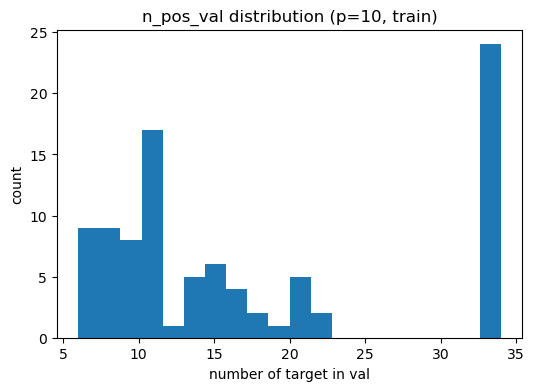

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(df_train["n_pos_val"].dropna(), bins=20)
plt.title("n_pos_val distribution (p=10, train)")
plt.xlabel("number of target in val")
plt.ylabel("count")
plt.show()

In [ ]:
# Проблемные субъекты
# 0 target в val — критично
df_train[df_train["n_pos_val"] == 0]

# мало target
df_train[df_train["n_pos_val"] < 2]

,subject_id,n_calib,n_pos_calib,n_pos_train,n_pos_val,error


Проблемные субъекты отсутствуют :)